<a href="https://colab.research.google.com/github/personallypetra/Grand_Challenge-/blob/Petra/PetraAccenture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%capture
!rm -rf Grand_Challenge
!git clone https://github.com/personallypetra/Grand_Challenge-.git
%cd Grand_Challenge-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine, inspect

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
import os
print(os.listdir("data_petra"))

['Export-DownloadCenterFile-20260312-012228.xlsx', 'Export-DownloadCenterFile-20260312-012232.xlsx', 'Export-DownloadCenterFile-20260311-234305.xlsx', 'Export-DownloadCenterFile-20260312-012253.xlsx', 'Export-DownloadCenterFile-20260311-234252.xlsx', 'Export-DownloadCenterFile-20260311-234217.xlsx', 'Export-DownloadCenterFile-20260312-012235.xlsx', 'Export-DownloadCenterFile-20260311-234258.xlsx', 'Export-DownloadCenterFile-20260312-012738.xlsx', 'Export-DownloadCenterFile-20260311-234315.xlsx', 'Export-DownloadCenterFile-20260311-234227.xlsx']


# Loading **Consumption** datasets and merging them into one csv file







In [6]:
def load_end_merge_excel( files ):
  dfs = [pd.read_excel(f) for f in files]
  df = pd.concat(dfs, ignore_index = True)
  return df

In [9]:
%%capture
files = ["data_petra/Export-DownloadCenterFile-20260311-234217.xlsx",
         "data_petra/Export-DownloadCenterFile-20260311-234227.xlsx",
         "data_petra/Export-DownloadCenterFile-20260311-234252.xlsx",
         "data_petra/Export-DownloadCenterFile-20260311-234258.xlsx",
         "data_petra/Export-DownloadCenterFile-20260311-234305.xlsx",
         "data_petra/Export-DownloadCenterFile-20260311-234315.xlsx"]

df = load_end_merge_excel(files)


### Checking shape and head

In this step, we are going to check the data inside our csv file to gain some insights.

In [12]:
print(f"Data Shape: {df.shape}")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(f"Data Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Memory Usage: {df.memory_usage().sum()/1e6:.2f}MB")
print(df.columns.tolist())

Data Shape: (1453829, 4)
Data Range: 2021-01-01 00:00:00 to 2026-03-10 23:45:00
Memory Usage: 46.52MB
['Date', 'Total Load [MW]', 'Forecast Total Load [MW]', 'Bidding Zone']


## Creating new csv file that contains daily consumption


The available database measures total load and forecast Total Load each 15 minutes. We are now creating new database that is going to contain same informations on daily basis.

In [22]:
df.columns  = df.columns.str.strip()
df["Bidding Zone"] = df["Bidding Zone"].astype(str).str.strip()


DailyConsumption = (df.groupby([
    pd.Grouper(key = "Date", freq = "D"), "Bidding Zone"])
    [["Total Load [MW]","Forecast Total Load [MW]"]].mean().reset_index())


## Descriptive overview of Consumption Dataset


In [23]:
DailyConsumption.describe(include = "all")

,Date,Bidding Zone,Total Load [MW],Forecast Total Load [MW]
count,15144,15144,15144.000000,15144.000000
unique,NaN,8,NaN,NaN
top,NaN,Calabria,NaN,NaN
freq,NaN,1893,NaN,NaN
mean,2023-08-05 01:22:09.318542080,NaN,8932.607433,8979.840883
min,2021-01-01 00:00:00,NaN,299.911594,296.230042
25%,2022-04-19 00:00:00,NaN,1506.394359,1500.229448
50%,2023-08-05 00:00:00,NaN,2840.720849,2862.258589
75%,2024-11-20 00:00:00,NaN,9216.453273,9351.040513
max,2026-03-10 00:00:00,NaN,49212.000042,49810.812667


Our dataset contains 15144 values of electricity load, measured in MW. We have 8 different `Bidding Zones` starting from 1<sup>st</sup> January 2021 to 10<sup>th</sup>January 2026.

### Creating wider table with dates as rows and regional consumptions of electricity as columns

By doing this we are gaining clearer view of our data.

In [27]:
DailyConsumption_Wide = DailyConsumption.pivot(index = "Date", columns = "Bidding Zone", values = ["Total Load [MW]", "Forecast Total Load [MW]"]).reset_index()
DailyConsumption.to_csv("DailyConsumption.csv", index = False)
DailyConsumption_Wide.to_csv("DailyConsumption_Wide.csv", index = False)

DailyConsumption_Wide.columns.name = None
print(DailyConsumption_Wide.head())


                   Date Total Load [MW]                            \
Bidding Zone                   Calabria Centre-North Centre-South   
0            2021-01-01      592.586505  2353.797260  4779.609458   
1            2021-01-02      626.306281  2478.478625  5197.343031   
2            2021-01-03      627.480115  2342.853312  5065.761927   
3            2021-01-04      733.124813  2969.801635  6072.452698   
4            2021-01-05      722.009979  3163.967812  6471.392354   

                                                                    \
Bidding Zone         Italy         North     Sardinia       Sicily   
0             25509.468729  12720.334229  1008.967958  1957.947396   
1             27544.197896  13923.800177  1045.211010  2100.798208   
2             26613.031198  13400.244250  1036.130698  2041.380677   
3             33755.541667  17876.990146  1109.121469  2263.508875   
4             35059.562646  18798.909760  1129.786948  2118.167458   

                         

## Checking for missing values if any

Before plotting, we would like to know if we are missing any consumption data. Moreover, if so, we would like to locate it and see what is the best way to overcome that issue.

In [28]:
DailyConsumption_Wide["Date"] = pd.to_datetime(DailyConsumption_Wide["Date"])

full_dates = pd.date_range(
    start = DailyConsumption_Wide["Date"].min(),
    end = DailyConsumption_Wide["Date"].max(),
    freq = "D"
)

missing_dates = full_dates[~full_dates.isin(DailyConsumption_Wide["Date"])]
print(missing_dates)
print(DailyConsumption_Wide.isna().sum())

DatetimeIndex(['2026-01-14', '2026-01-15'], dtype='datetime64[ns]', freq='D')
                          Bidding Zone
Date                                      0
Total Load [MW]           Calabria        0
                          Centre-North    0
                          Centre-South    0
                          Italy           0
                          North           0
                          Sardinia        0
                          Sicily          0
                          South           0
Forecast Total Load [MW]  Calabria        0
                          Centre-North    0
                          Centre-South    0
                          Italy           0
                          North           0
                          Sardinia        0
                          Sicily          0
                          South           0
dtype: int64


Based on this results, we can conclude that there are two days missing (14th and 15th January 2026). Furthermore, there are no missing values for any other day present in any of regions. Since they represent &lt;0.1% of the data, we apply *linear interpolation* to preserve continuity.







In [29]:
DailyConsumption_Wide = DailyConsumption_Wide.set_index("Date").interpolate().reset_index()

---
## Checking for Duplicates

One more step before we proceed with plotting our data. We don't expect any duplicates, but better to be safe than sorry.

In [19]:
print("Duplicate dates:", DailyConsumption_Wide_actual["Date"].duplicated().sum())

Duplicate dates: 0


## Forecast Accuracy Analysis


In [32]:
DailyConsumption["Forecast_Error"] = DailyConsumption["Forecast Total Load [MW]"] - DailyConsumption["Total Load [MW]"]
DailyConsumption["Abs_Percent_Error"] = abs(DailyConsumption["Forecast_Error"] / DailyConsumption["Total Load [MW]"]) * 100

error_stats = DailyConsumption.groupby("Bidding Zone")["Abs_Percent_Error"].mean().sort_values()
print(error_stats)


Bidding Zone
South           1.222272
North           1.223487
Italy           1.225324
Sardinia        1.225694
Sicily          1.226708
Calabria        1.227102
Centre-North    1.230617
Centre-South    1.230912
Name: Abs_Percent_Error, dtype: float64


From the results calculated above, we can see that the prediction error remains almost the same between regions. It's averaging 1.22 - 1.23% overall, which suggests that the forecasted electricity load is solidly accurate with only small deviations from the observed values.

## Plotting Consumption data


---

We are going to make 2 plots – one with each region's consumption and one for the whole Italy.


---
### Regional Consumption


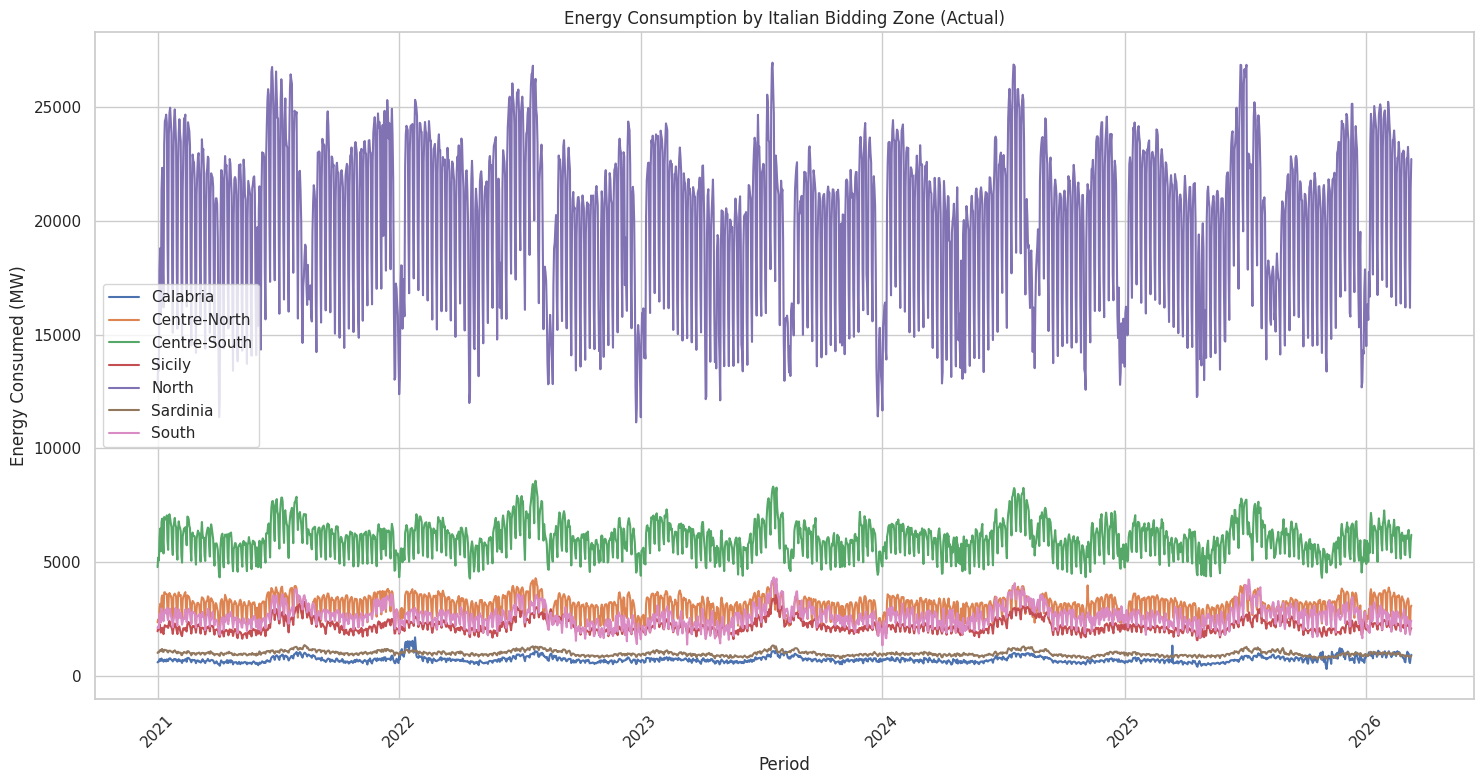

In [38]:
plt.figure(figsize=(15, 8))
regions = [
    "Calabria",
    "Centre-North",
    "Centre-South",
    "Sicily",
    "North",
    "Sardinia",
    "South"
]

for region in regions:
  plt.plot(DailyConsumption_Wide["Date"],
           DailyConsumption_Wide["Total Load [MW]", region], label=region)

plt.xlabel("Period")
plt.ylabel("Energy Consumed (MW)")
plt.title("Energy Consumption by Italian Bidding Zone (Actual)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This graph illustrates the electricity consumption by each region. `North` region shows constantly biggest consumption of electricity, whereas, region `Calabria` remains (almost) constantly the lowest consumption region.


---
### Italy's Consumption




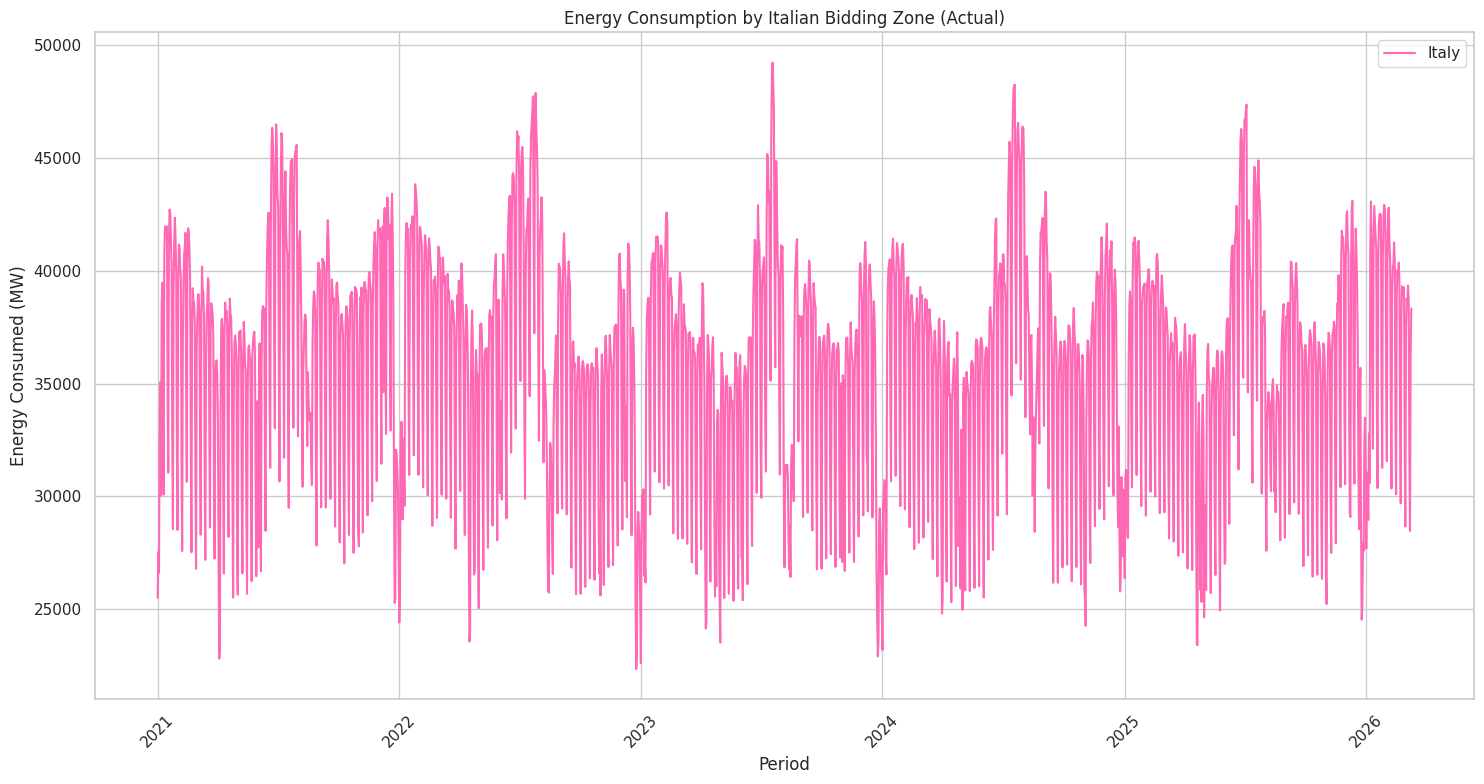

In [39]:
plt.figure(figsize=(15, 8))

plt.plot(DailyConsumption_Wide["Date"], DailyConsumption_Wide[("Total Load [MW]", "Italy")], label="Italy", color = "#FF69B4")

plt.xlabel("Period")
plt.ylabel("Energy Consumed (MW)")
plt.title("Energy Consumption by Italian Bidding Zone (Actual)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This graph shows the daily electricity consumption in Italy. Overall, demand fluctuates significantly. However it follows clear seasonal trend, that includes:
- peaks close to 49000 MW;
- lows around 23000 - 26000 MW.

Aside short-term variations, the general level seems to be stable over time.

---
# Loading **Energy Production** datasets and merging them


In [42]:
%%capture
files = [ "data_petra/Export-DownloadCenterFile-20260312-012228.xlsx",
          "data_petra/Export-DownloadCenterFile-20260312-012232.xlsx",
          "data_petra/Export-DownloadCenterFile-20260312-012235.xlsx",
          "data_petra/Export-DownloadCenterFile-20260312-012253.xlsx",
          "data_petra/Export-DownloadCenterFile-20260312-012738.xlsx"]

df = load_end_merge_excel(files)

In [43]:
print(f"Data Shape: {df.shape}")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(f"Data Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Memory Usage: {df.memory_usage().sum()/1e6:.2f}MB")
print(df.columns.tolist())

Data Shape: (420593, 3)
Data Range: 2021-01-01 00:00:00 to 2025-12-31 23:45:00
Memory Usage: 10.09MB
['Date', 'Actual Generation', 'Primary Source']


In [44]:
df = df[~df["Date"].astype(str).str.contains("Applied filters", na=False)].copy()
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

DailyEnergyProduction = (
    df.assign(Day=df["Date"].dt.floor("D"))
      .groupby(["Day", "Primary Source"], as_index=False)["Actual Generation"]
      .mean()
)

print(DailyEnergyProduction["Day"].min())
print(DailyEnergyProduction["Day"].max())

2021-01-01 00:00:00
2025-12-31 00:00:00


## Finding unique sources

In this part, we are going to find our key primary sources of electrical energy generators.  

In [51]:
print((DailyEnergyProduction["Primary Source"]).unique())

['Geothermal' 'Hydro' 'Photovoltaic' 'Self-consumption' 'Thermal' 'Wind']


In [52]:
DailyEnergyProduction.describe(include = "all")

,Day,Primary Source,Actual Generation
count,10956,10956,10956.000000
unique,NaN,6,NaN
top,NaN,Geothermal,NaN
freq,NaN,1826,NaN
mean,2023-07-02 12:00:00,NaN,5.098338
min,2021-01-01 00:00:00,NaN,0.144583
25%,2022-04-02 00:00:00,NaN,1.403125
50%,2023-07-02 12:00:00,NaN,3.382917
75%,2024-10-01 00:00:00,NaN,5.340521
max,2025-12-31 00:00:00,NaN,31.674167


We have 10956 Our data set covers the period from 1<sup>st</sup> January 2021 to 31<sup>st</sup> December 2025.



Since the data above covers the Lazio Region, in order to see how much of the consumed energy came from the previously mentioned sources, we are going to extract data from 'TotalDailyLoad' about 'Centre-South' region.


### Adjusting 2025 to rest of the dataset values


---



In [53]:
DailyEnergyProduction["Day"] = pd.to_datetime(DailyEnergyProduction["Day"])

df_2024 = DailyEnergyProduction[
    (DailyEnergyProduction["Day"] >= "2024-01-01") &
    (DailyEnergyProduction["Day"] <= "2024-01-05")
]

df_2025 = DailyEnergyProduction[
    (DailyEnergyProduction["Day"] >= "2025-01-01") &
    (DailyEnergyProduction["Day"] <= "2025-01-05")
]
print(DailyEnergyProduction["Day"].min())
print(DailyEnergyProduction["Day"].max())
print(DailyEnergyProduction["Day"].head())

mean_2024 = df_2024.groupby("Primary Source")["Actual Generation"].mean()
print(mean_2024)
mean_2025 = df_2025.groupby("Primary Source")["Actual Generation"].mean()
print(mean_2025)

2021-01-01 00:00:00
2025-12-31 00:00:00
0   2021-01-01
1   2021-01-01
2   2021-01-01
3   2021-01-01
4   2021-01-01
Name: Day, dtype: datetime64[ns]
Primary Source
Geothermal           0.626333
Hydro                3.665000
Photovoltaic         1.084000
Self-consumption     2.002833
Thermal             11.904417
Wind                 4.434583
Name: Actual Generation, dtype: float64
Primary Source
Geothermal           0.611083
Hydro                3.467667
Photovoltaic         1.527167
Self-consumption     2.381692
Thermal             13.632500
Wind                 2.591750
Name: Actual Generation, dtype: float64


In [54]:
energy_plt = DailyEnergyProduction.pivot(
    index="Day",
    columns="Primary Source",
    values="Actual Generation"
).reset_index()
energy_plt["Total"] = energy_plt[["Geothermal", "Hydro", "Photovoltaic", "Self-consumption", "Thermal", "Wind"]].sum(axis = 1)
energy_plt["Media"] = energy_plt[["Geothermal", "Hydro", "Photovoltaic", "Self-consumption", "Thermal", "Wind"]].mean(axis = 1)


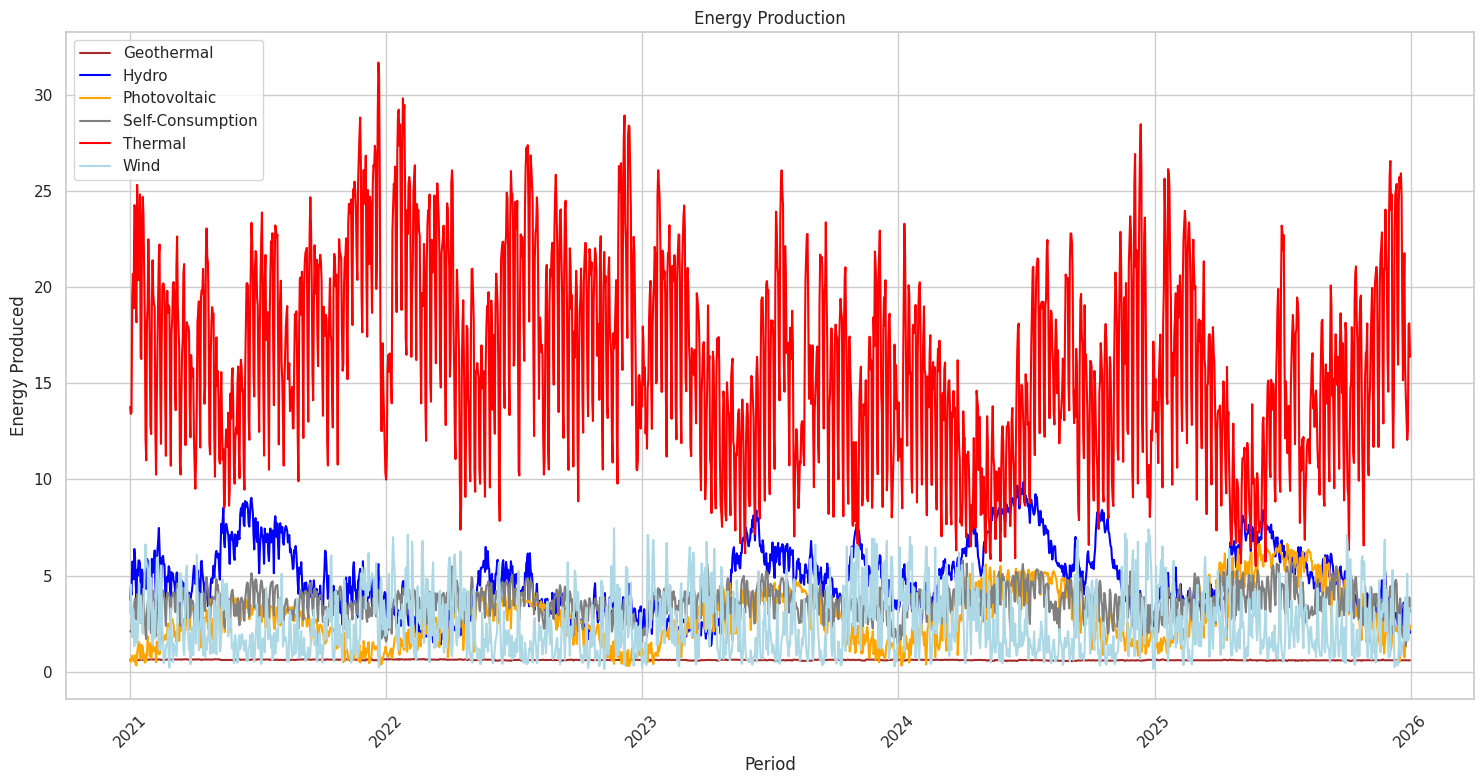

In [49]:
plt.figure(figsize = (15, 8))

plt.plot(energy_plt["Day"], energy_plt["Geothermal"], color = "brown", label = "Geothermal")
plt.plot(energy_plt["Day"], energy_plt["Hydro"], color = "blue", label = "Hydro")
plt.plot(energy_plt["Day"], energy_plt["Photovoltaic"], color = "orange", label = "Photovoltaic")
plt.plot(energy_plt["Day"], energy_plt["Self-consumption"], color = "grey", label = "Self-Consumption")
plt.plot(energy_plt["Day"], energy_plt["Thermal"], color = "red", label = "Thermal")
plt.plot(energy_plt["Day"], energy_plt["Wind"], color = "lightblue", label = "Wind")


plt.xlabel("Period")
plt.ylabel("Energy Produced")
plt.title("Energy Production")
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Pie-Chart approach (yearly)



---
In this section, we are broathening our visual representations.




In [70]:
yearly_production = (DailyEnergyProduction.assign(
    Year = DailyEnergyProduction["Day"].dt.year).groupby(
        ["Year", "Primary Source"])["Actual Generation"].mean().reset_index())

yearly_pivot = yearly_production.pivot( index = "Year", columns = "Primary Source", values = "Actual Generation")

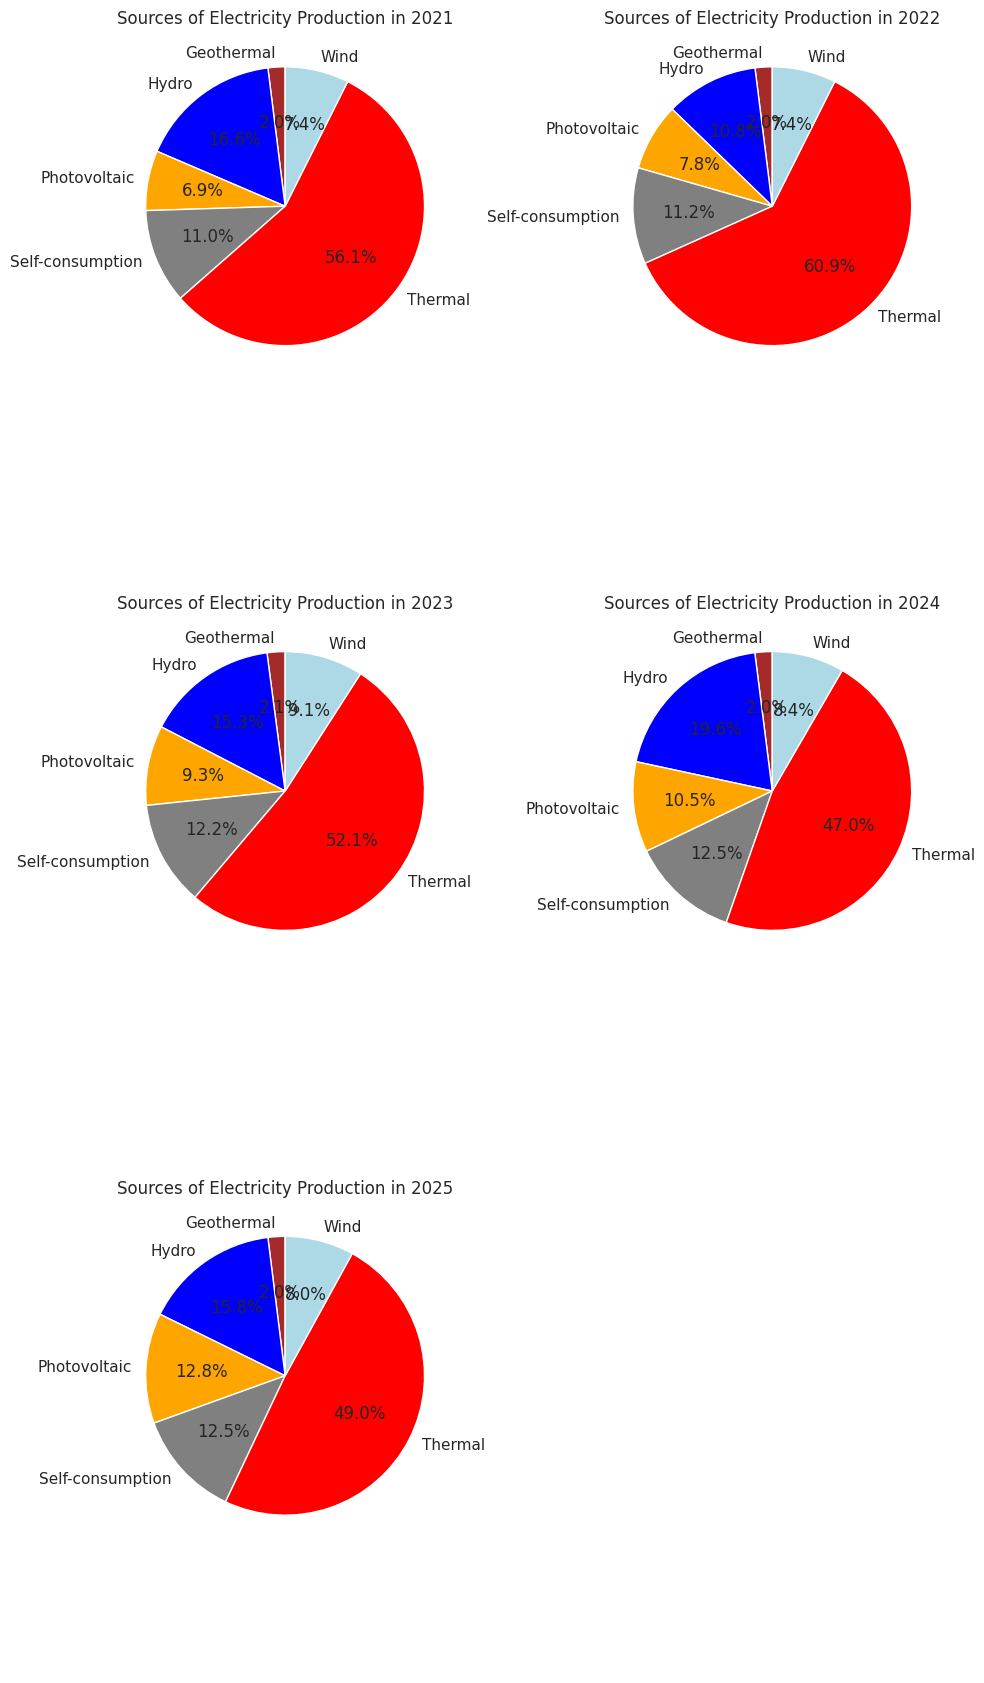

In [77]:
colors = {
    "Thermal" : "red",
    "Hydro" : "blue",
    "Wind" : "lightblue",
    "Photovoltaic" : "orange",
    "Geothermal" : "brown",
    "Self-consumption" : "grey"
}
years = yearly_pivot.index.tolist()
n = len(years)
fig, axes = plt.subplots(nrows=(n+1)//2, ncols=2, figsize=(10, 6*((n+1)//2)))
axes = axes.flatten()

for i, year in enumerate(years):
  values = yearly_pivot.loc[year]
  axes[i].pie(
      values, labels = values.index, autopct = "%1.1f%%", colors = [colors[i] for i in values.index],
      startangle = 90)
  axes[i].set_title(f"Sources of Electricity Production in {year}")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()



